# 01 — Corpus Exploration

**Goals:**
- Understand score distribution and skew across the 18k BIPs
- Profile BIP text: length, vocabulary, structural patterns
- Explore metadata: supervisors, districts, rurality, school years
- Identify how many unique elements/rubric dimensions exist
- Quantify missing data and flag data quality issues
- Produce summary stats that directly inform pipeline config

**Outputs used downstream:**
- Score distribution → `AnchorSamplerConfig.n_per_level` oversampling ratios
- Length distribution → `GenerationConfig.max_tokens` target range
- Supervisor/district counts → audit subgroup feasibility
- Missing score rate → how many BIPs are actually usable

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
SEED = 42
DATA_PATH = Path('../data/raw')  # adjust to your actual path

## 1. Load and Inspect

In [ ]:
# adjust filename as needed
df = pd.read_csv(DATA_PATH / 'bips.csv', low_memory=False)

print(f'Shape: {df.shape}')
print(f'\nColumns:\n{df.columns.tolist()}')

Shape: (19719, 15)

Columns:
['PersonId', 'SchoolYear', 'BuildingID', 'DistrictID', 'CreatedDate', 'noconcat', 'Rurality', 'year_num', 'totalBIPs', 'no_score', 'Element_numberX', 'supervisor_commentX', 'prob4_ElementX', 'Supervisor_Score_x', 'Text']


,PersonId,SchoolYear,BuildingID,DistrictID,CreatedDate,noconcat,Rurality,year_num,totalBIPs,no_score,Element_numberX,supervisor_commentX,prob4_ElementX,Supervisor_Score_x,Text
0,0000CCE6-BC16-E511-80C0-005056B067F1,2016-2017,11A9EA3F-5E13-E511-80C0-005056B067F1,D5A2EA3F-5E13-E511-80C0-005056B067F1,10oct2016 20:44:49,1,32,2017.0,1.0,0,Element1,NaN,0.995902,4.0,"As the building Assistant Principal, I am prim..."
1,0000CCE6-BC16-E511-80C0-005056B067F1,2017-2018,11A9EA3F-5E13-E511-80C0-005056B067F1,D5A2EA3F-5E13-E511-80C0-005056B067F1,10oct2017 00:37:10,1,32,2018.0,1.0,0,Element1,NaN,0.991316,4.0,"As the building Assistant Principal, I am prim..."
2,0005CCE6-BC16-E511-80C0-005056B067F1,2015-2016,9CA6EA3F-5E13-E511-80C0-005056B067F1,25A2EA3F-5E13-E511-80C0-005056B067F1,02oct2015 14:15:50,1,42,2016.0,1.0,0,Element1,NaN,0.160476,3.0,As Diamond Middle School principal I spearhead...


In [4]:
# data types and nulls
null_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
print(null_summary.to_string())

                       dtype  null_count  null_pct
PersonId              object           0      0.00
SchoolYear            object           0      0.00
BuildingID            object           0      0.00
DistrictID            object           0      0.00
CreatedDate           object           0      0.00
noconcat               int64           0      0.00
Rurality               int64           0      0.00
year_num             float64        5397     27.37
totalBIPs            float64        5397     27.37
no_score               int64           0      0.00
Element_numberX       object           0      0.00
supervisor_commentX   object       14437     73.21
prob4_ElementX       float64        5397     27.37
Supervisor_Score_x   float64        5848     29.66
Text                  object        1319      6.69


In [5]:
# how many unique people, schools, districts, supervisors
id_cols = ['PersonId', 'BuildingID', 'DistrictID']
for col in id_cols:
    if col in df.columns:
        print(f'{col}: {df[col].nunique():,} unique')

print(f'\nSchool years: {sorted(df["SchoolYear"].unique()) if "SchoolYear" in df.columns else "N/A"}')
print(f'Rurality values: {df["Rurality"].unique() if "Rurality" in df.columns else "N/A"}')

PersonId: 1,086 unique
BuildingID: 612 unique
DistrictID: 156 unique

School years: ['2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024']
Rurality values: [32 42 33 21 23 41 43 31 13 11 12]


## 2. Score Distribution (Core Motivation)

In [6]:
score_col = 'Supervisor_Score_x'  # adjust if your column name differs

print('=== Raw score distribution ===')
print(df[score_col].value_counts(dropna=False).sort_index())
print(f'\nMissing scores: {df[score_col].isnull().sum():,} ({df[score_col].isnull().mean()*100:.1f}%)')
print(f'no_score flag set: {df["no_score"].sum():,}' if 'no_score' in df.columns else '')

=== Raw score distribution ===
Supervisor_Score_x
0.0      122
1.0      116
2.0      615
3.0     2525
4.0    10493
NaN     5848
Name: count, dtype: int64

Missing scores: 5,848 (29.7%)
no_score flag set: 5,397


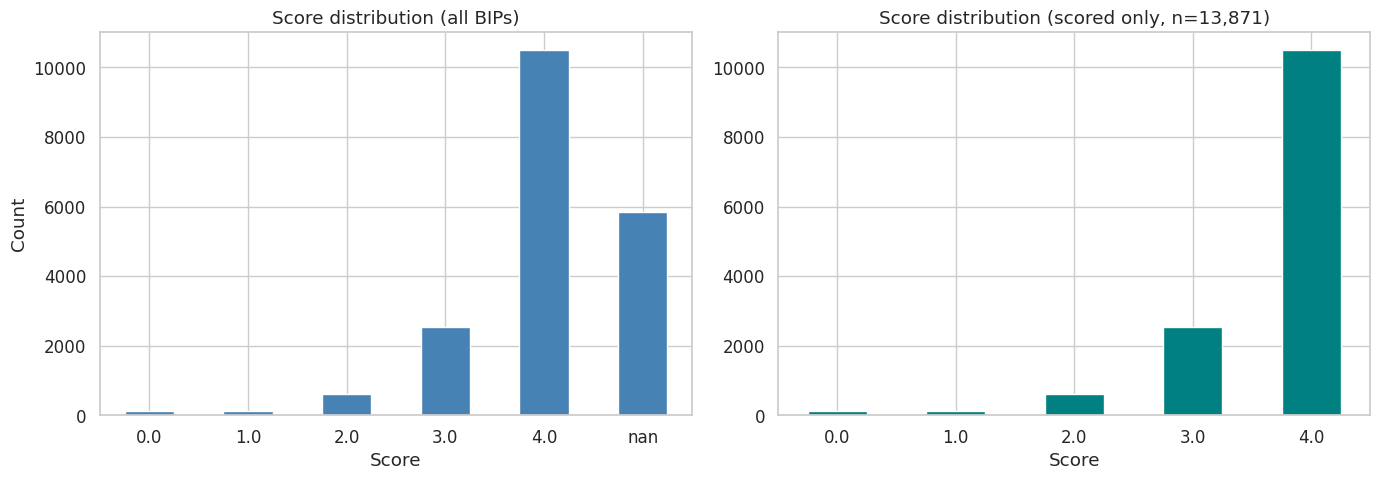


Scored BIPs: 13,871 / 19,719 (70.3%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# full distribution including nulls
score_counts = df[score_col].value_counts(dropna=False).sort_index()
score_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Score distribution (all BIPs)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# scored only
scored = df[df[score_col].notna()]
scored[score_col].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='teal', edgecolor='white'
)
axes[1].set_title(f'Score distribution (scored only, n={len(scored):,})')
axes[1].set_xlabel('Score')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../results/diagnostics/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nScored BIPs: {len(scored):,} / {len(df):,} ({len(scored)/len(df)*100:.1f}%)')

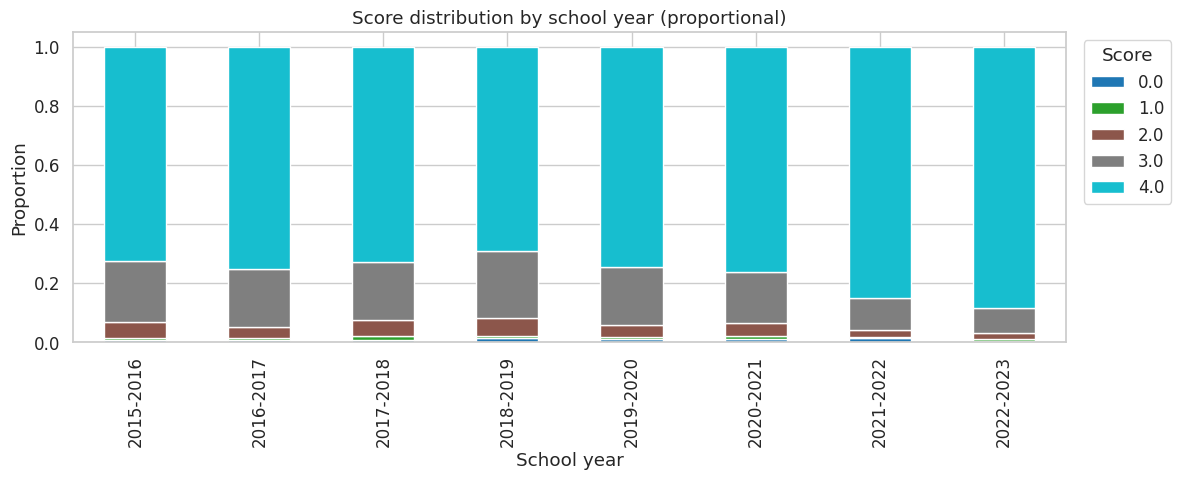

In [8]:
# score distribution over time — is skew getting worse?
if 'SchoolYear' in df.columns and 'year_num' in df.columns:
    score_by_year = scored.groupby('SchoolYear')[score_col].value_counts(
        normalize=True
    ).unstack().fillna(0)
    
    score_by_year.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='tab10')
    plt.title('Score distribution by school year (proportional)')
    plt.xlabel('School year')
    plt.ylabel('Proportion')
    plt.legend(title='Score', bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.savefig('../results/diagnostics/score_by_year.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. Supervisor-Level Analysis

In [9]:
# BIPs per supervisor — do we have enough per supervisor for subgroup analysis?
# PersonId likely = principal; look for a supervisor identifier in your data
# If supervisor is implicit (per district), use DistrictID as proxy

if 'DistrictID' in df.columns:
    district_counts = scored.groupby('DistrictID').agg(
        n_bips=(score_col, 'count'),
        mean_score=(score_col, 'mean'),
        std_score=(score_col, 'std')
    ).sort_values('n_bips', ascending=False)

    print(f'Districts with >= 30 scored BIPs: {(district_counts.n_bips >= 30).sum()}')
    print(f'Districts with >= 10 scored BIPs: {(district_counts.n_bips >= 10).sum()}')
    print(f'\nTop 10 districts by volume:')
    print(district_counts.head(10).to_string())
    
    # mean score variance across districts — this is the bias signal
    print(f'\nMean score range across districts: '
          f'{district_counts.mean_score.min():.2f} – {district_counts.mean_score.max():.2f}')
    print(f'Std of district mean scores: {district_counts.mean_score.std():.3f}')

Districts with >= 30 scored BIPs: 62
Districts with >= 10 scored BIPs: 95

Top 10 districts by volume:
                                      n_bips  mean_score  std_score
DistrictID                                                         
87A2EA3F-5E13-E511-80C0-005056B067F1    1216    3.117599   0.976339
33A1EA3F-5E13-E511-80C0-005056B067F1    1102    3.940109   0.237393
A5A1EA3F-5E13-E511-80C0-005056B067F1    1065    3.972770   0.199177
ACA2EA3F-5E13-E511-80C0-005056B067F1     859    3.868452   0.367907
D1A1EA3F-5E13-E511-80C0-005056B067F1     806    3.978908   0.160130
C2A1EA3F-5E13-E511-80C0-005056B067F1     498    3.823293   0.550196
6CA1EA3F-5E13-E511-80C0-005056B067F1     488    3.807377   0.590641
F0A1EA3F-5E13-E511-80C0-005056B067F1     472    3.807203   0.464117
2EA2EA3F-5E13-E511-80C0-005056B067F1     398    3.826633   0.612707
82A2EA3F-5E13-E511-80C0-005056B067F1     315    3.742857   0.492528

Mean score range across districts: 2.18 – 4.00
Std of district mean scores: 0.40

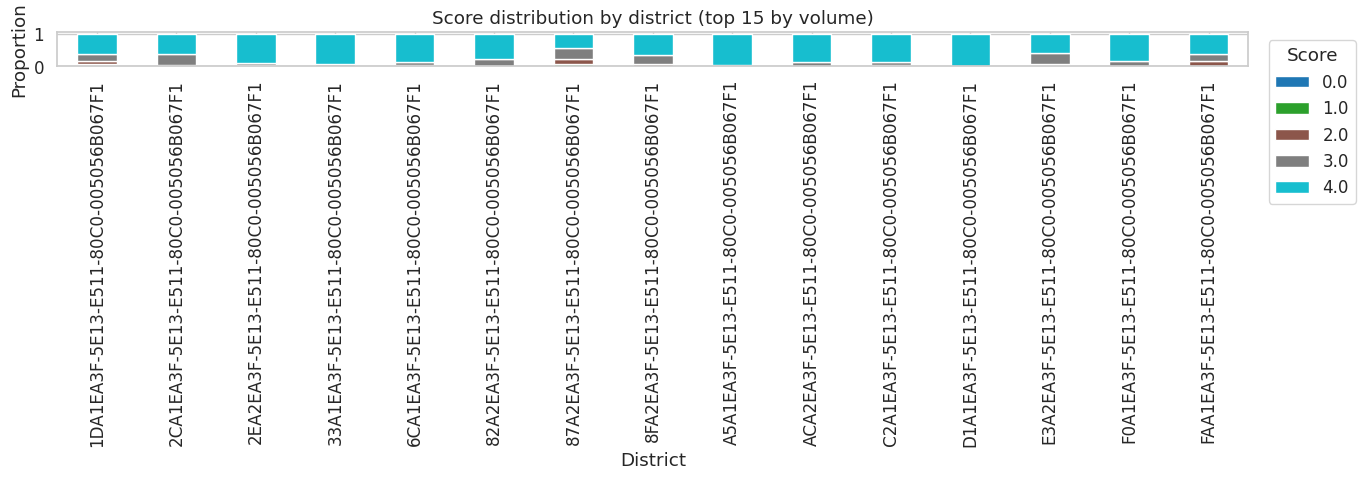

In [10]:
# score distribution variance across districts
if 'DistrictID' in df.columns:
    # sample top 15 districts by volume
    top_districts = district_counts.head(15).index
    subset = scored[scored['DistrictID'].isin(top_districts)]
    
    fig, ax = plt.subplots(figsize=(14, 5))
    district_score_pct = subset.groupby('DistrictID')[score_col].value_counts(
        normalize=True
    ).unstack().fillna(0)
    district_score_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
    ax.set_title('Score distribution by district (top 15 by volume)')
    ax.set_xlabel('District')
    ax.set_ylabel('Proportion')
    ax.legend(title='Score', bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.savefig('../results/diagnostics/score_by_district.png', dpi=150, bbox_inches='tight')
    plt.show()

=== Score distribution by rurality ===
Supervisor_Score_x    0.0    1.0    2.0    3.0    4.0
Rurality                                             
11                  0.002  0.004  0.027  0.096  0.871
13                    NaN    NaN  0.006    NaN  0.994
21                  0.006  0.012  0.051  0.150  0.781
23                  0.006  0.006  0.024  0.086  0.878
31                  0.010  0.007  0.030  0.146  0.807
32                  0.008  0.004  0.022  0.164  0.803
33                  0.016  0.007  0.042  0.231  0.704
41                  0.020  0.002  0.047  0.241  0.690
42                  0.013  0.011  0.088  0.297  0.590
43                  0.010  0.006  0.068  0.409  0.507


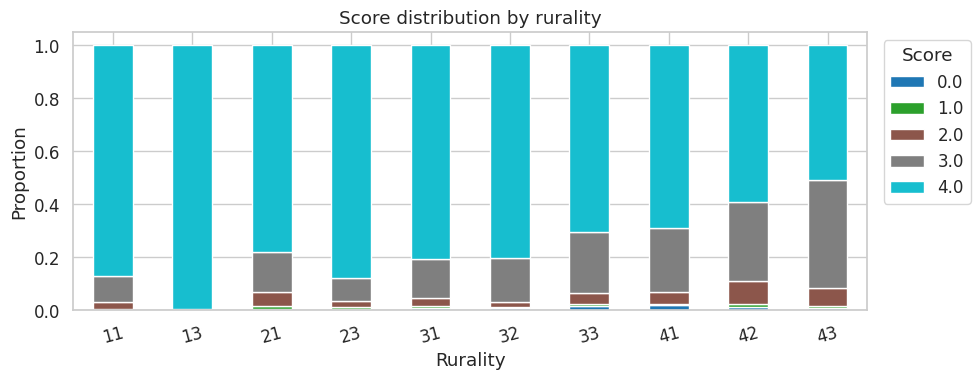

In [11]:
# rurality breakdown
if 'Rurality' in df.columns:
    print('=== Score distribution by rurality ===')
    print(scored.groupby('Rurality')[score_col].value_counts(
        normalize=True
    ).unstack().round(3).to_string())
    
    fig, ax = plt.subplots(figsize=(10, 4))
    scored.groupby('Rurality')[score_col].value_counts(
        normalize=True
    ).unstack().fillna(0).plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
    ax.set_title('Score distribution by rurality')
    ax.set_xlabel('Rurality')
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Score', bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.savefig('../results/diagnostics/score_by_rurality.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. BIP Text Analysis

In [12]:
text_col = 'Text'  # the BIP text column

# basic text stats
scored['token_count'] = scored[text_col].fillna('').apply(lambda x: len(x.split()))
scored['char_count']  = scored[text_col].fillna('').apply(len)
scored['sent_count']  = scored[text_col].fillna('').apply(
    lambda x: x.count('.') + x.count('!') + x.count('?')
)

print('=== Token count stats ===')
print(scored['token_count'].describe().round(1).to_string())
print(f'\nEmpty/null BIPs: {(scored[text_col].fillna("") == "").sum()}')

=== Token count stats ===
count    13871.0
mean       175.3
std        240.3
min          0.0
25%         47.0
50%        104.0
75%        212.0
max       3940.0

Empty/null BIPs: 522


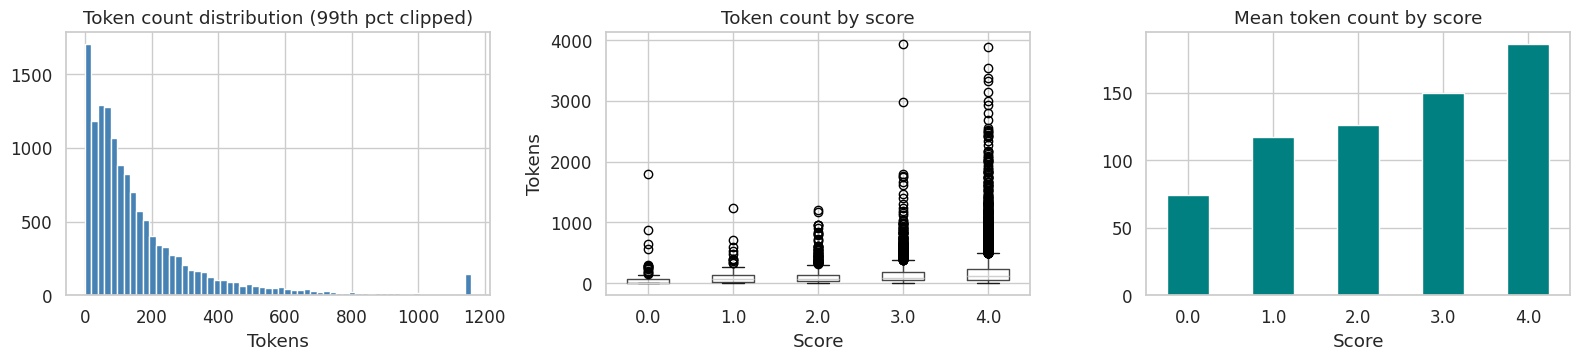


Token count by score level:
                      count   mean    std  min   25%    50%    75%     max
Supervisor_Score_x                                                        
0.0                   122.0   74.5  202.6  0.0   0.0    1.0   63.0  1804.0
1.0                   116.0  117.2  168.2  0.0  18.8   66.0  142.2  1233.0
2.0                   615.0  126.1  170.1  0.0  29.5   63.0  143.5  1212.0
3.0                  2525.0  150.1  201.7  0.0  46.0   90.0  180.0  3940.0
4.0                 10493.0  186.0  252.0  0.0  51.0  114.0  228.0  3878.0


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# token count distribution
scored['token_count'].clip(upper=scored['token_count'].quantile(0.99)).hist(
    bins=60, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Token count distribution (99th pct clipped)')
axes[0].set_xlabel('Tokens')

# token count by score
scored.boxplot(column='token_count', by=score_col, ax=axes[1])
axes[1].set_title('Token count by score')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Tokens')
plt.sca(axes[1])
plt.title('Token count by score')

# mean token count per score level
scored.groupby(score_col)['token_count'].mean().plot(
    kind='bar', ax=axes[2], color='teal', edgecolor='white'
)
axes[2].set_title('Mean token count by score')
axes[2].set_xlabel('Score')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('')
plt.tight_layout()
plt.savefig('../results/diagnostics/text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nToken count by score level:')
print(scored.groupby(score_col)['token_count'].describe().round(1).to_string())

In [14]:
# how many BIPs are extremely short (potentially empty / low quality)?
thresholds = [10, 25, 50, 100]
print('Short BIP analysis:')
for t in thresholds:
    n = (scored['token_count'] < t).sum()
    print(f'  < {t} tokens: {n:,} ({n/len(scored)*100:.1f}%)')

print(f'\nRecommended min token filter for style learner training: TBD based on above')

Short BIP analysis:
  < 10 tokens: 1,236 (8.9%)
  < 25 tokens: 1,980 (14.3%)
  < 50 tokens: 3,634 (26.2%)
  < 100 tokens: 6,660 (48.0%)

Recommended min token filter for style learner training: TBD based on above


In [15]:
# vocabulary analysis
from collections import Counter
import re

def tokenize(text):
    return re.findall(r'\b[a-z]+\b', str(text).lower())

# sample for speed — full corpus would be slow in a notebook
sample = scored.sample(min(3000, len(scored)), random_state=SEED)
all_tokens = [t for text in sample[text_col].fillna('') for t in tokenize(text)]

vocab = Counter(all_tokens)
print(f'Unique tokens in sample: {len(vocab):,}')
print(f'Total tokens in sample: {len(all_tokens):,}')
print(f'Type-token ratio: {len(vocab)/len(all_tokens):.4f}')
print(f'\nTop 30 most frequent words:')
print([w for w, _ in vocab.most_common(30)])

Unique tokens in sample: 12,906
Total tokens in sample: 520,904
Type-token ratio: 0.0248

Top 30 most frequent words:
['the', 'and', 'to', 'of', 'in', 'will', 'for', 'a', 'students', 'data', 'with', 'on', 'school', 'our', 'be', 'as', 'by', 'student', 'we', 'team', 'year', 'that', 'staff', 'is', 'building', 'at', 'are', 'this', 'teachers', 'learning']


In [16]:
# vocabulary by score level — do higher-scoring BIPs use different language?
score_vocab = {}
for score in sorted(scored[score_col].dropna().unique()):
    sub = scored[scored[score_col] == score].sample(
        min(500, (scored[score_col] == score).sum()), random_state=SEED
    )
    tokens = [t for text in sub[text_col].fillna('') for t in tokenize(text)]
    score_vocab[score] = Counter(tokens)

# type-token ratio by score
print('Type-token ratio by score:')
for score, cnt in score_vocab.items():
    total = sum(cnt.values())
    ttr = len(cnt) / total if total > 0 else 0
    print(f'  Score {score}: {ttr:.4f} (vocab size {len(cnt):,})')

Type-token ratio by score:
  Score 0.0: 0.1955 (vocab size 1,763)
  Score 1.0: 0.1565 (vocab size 2,074)
  Score 2.0: 0.0721 (vocab size 4,482)
  Score 3.0: 0.0645 (vocab size 4,984)
  Score 4.0: 0.0641 (vocab size 5,653)


## 5. Rubric Element Analysis

In [17]:
# Element_numberX — understand rubric dimensions present in the data
element_col = 'Element_numberX'  # adjust if needed

if element_col in df.columns:
    print('=== Rubric elements ===')
    print(scored[element_col].value_counts().to_string())
    print(f'\nUnique elements: {scored[element_col].nunique()}')
    print(f'Missing element label: {scored[element_col].isnull().sum():,}')

=== Rubric elements ===
Element_numberX
Element3    2005
Element1    1998
Element2    1997
Element4    1988
Element5    1980
Element6    1962
Element7    1941

Unique elements: 7
Missing element label: 0


Score distribution by element (proportional):
Supervisor_Score_x    0.0    1.0    2.0    3.0    4.0
Element_numberX                                      
Element1            0.002  0.004  0.028  0.183  0.784
Element2            0.000  0.006  0.035  0.184  0.776
Element3            0.000  0.003  0.026  0.134  0.837
Element4            0.008  0.008  0.048  0.198  0.738
Element5            0.011  0.014  0.048  0.165  0.762
Element6            0.018  0.012  0.056  0.218  0.697
Element7            0.023  0.013  0.072  0.193  0.699


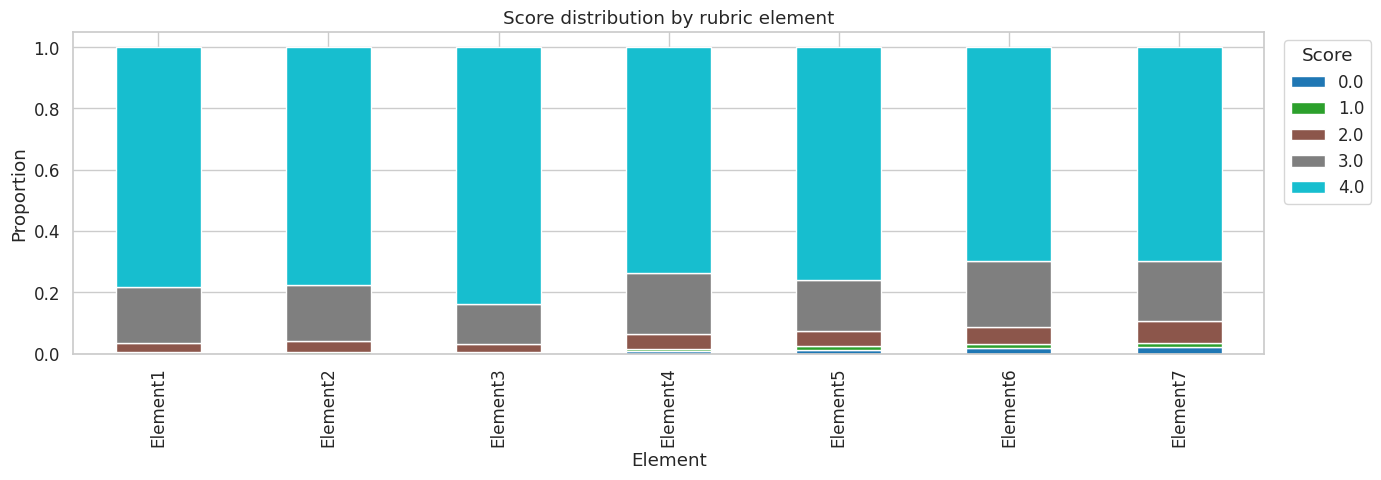

In [18]:
# score distribution per element — some elements may be scored harder
if element_col in df.columns:
    element_score = scored.groupby(element_col)[score_col].value_counts(
        normalize=True
    ).unstack().fillna(0)
    
    print('Score distribution by element (proportional):')
    print(element_score.round(3).to_string())
    
    if len(element_score) <= 20:  # only plot if manageable
        element_score.plot(kind='bar', stacked=True, figsize=(14, 5), colormap='tab10')
        plt.title('Score distribution by rubric element')
        plt.xlabel('Element')
        plt.ylabel('Proportion')
        plt.legend(title='Score', bbox_to_anchor=(1.01, 1))
        plt.tight_layout()
        plt.savefig('../results/diagnostics/score_by_element.png', dpi=150, bbox_inches='tight')
        plt.show()

In [19]:
# prob4_ElementX — what is this field? inspect it
prob_col = 'prob4_ElementX'
if prob_col in df.columns:
    print(f'=== {prob_col} ===')
    print(f'dtype: {df[prob_col].dtype}')
    print(f'null: {df[prob_col].isnull().sum():,}')
    print(f'\nValue counts (top 20):')
    print(df[prob_col].value_counts().head(20).to_string())
    print(f'\nDescribe:')
    print(df[prob_col].describe().to_string())

=== prob4_ElementX ===
dtype: float64
null: 5,397

Value counts (top 20):
prob4_ElementX
0.995902    144
0.980098    144
0.979110    144
0.974717    144
0.990896    144
0.994957    144
0.974918    144
0.976668    132
0.980913    132
0.984163    132
0.983228    132
0.957131    132
0.997710    132
0.980310    132
0.993694    126
0.997349    126
0.996340    126
0.993552    126
0.991316    126
0.989992    126

Describe:
count    14322.000000
mean         0.771620
std          0.299788
min          0.000031
25%          0.605692
50%          0.955074
75%          0.990896
max          0.999457


## 6. Supervisor Comment Analysis

In [20]:
comment_col = 'supervisor_commentX'

if comment_col in df.columns:
    has_comment = scored[comment_col].notna() & (scored[comment_col].str.strip() != '')
    print(f'BIPs with supervisor comment: {has_comment.sum():,} ({has_comment.mean()*100:.1f}%)')
    
    scored['comment_len'] = scored[comment_col].fillna('').apply(lambda x: len(x.split()))
    print(f'\nComment length stats:')
    print(scored.loc[has_comment, 'comment_len'].describe().round(1).to_string())
    
    # does having a comment correlate with lower scores?
    print('\nMean score — with vs without comment:')
    print(scored.groupby(has_comment)[score_col].mean().round(3))

BIPs with supervisor comment: 5,282 (38.1%)

Comment length stats:
count    5282.0
mean       23.8
std        21.5
min         1.0
25%        12.0
50%        19.0
75%        29.0
max       371.0

Mean score — with vs without comment:
supervisor_commentX
False    3.741
True     3.551
Name: Supervisor_Score_x, dtype: float64


## 7. noconcat Field

In [21]:
# understand what noconcat represents
if 'noconcat' in df.columns:
    print('=== noconcat ===')
    print(f'dtype: {df["noconcat"].dtype}')
    print(f'null: {df["noconcat"].isnull().sum():,}')
    print(f'\nValue counts:')
    print(df['noconcat'].value_counts(dropna=False).head(20).to_string())
    
    # is noconcat == 1 related to missing scores?
    if df['noconcat'].dtype in [int, float, 'int64', 'float64']:
        print(f'\nno_score rate by noconcat flag:')
        print(df.groupby('noconcat')['no_score'].mean().round(3)
              if 'no_score' in df.columns else 'no_score column not found')

=== noconcat ===
dtype: int64
null: 0

Value counts:
noconcat
1    17647
0     2072

no_score rate by noconcat flag:
noconcat
0    0.264
1    0.275
Name: no_score, dtype: float64


## 8. BIPs Per Principal — Longitudinal Structure

In [22]:
# how many BIPs does each principal have?
if 'PersonId' in df.columns:
    bips_per_person = df.groupby('PersonId').size()
    print('BIPs per principal:')
    print(bips_per_person.describe().round(1).to_string())
    print(f'\nPrincipals with only 1 BIP: {(bips_per_person == 1).sum():,}')
    print(f'Principals with >= 3 BIPs: {(bips_per_person >= 3).sum():,}')
    
    # note: principals with multiple BIPs are potential data leakage risk
    # during train/test splits — flag this for dataset.py
    print('\n⚠ NOTE: principals with multiple BIPs require group-based splits')
    print('  to avoid leakage. Flag in src/data/dataset.py.')

BIPs per principal:
count    1086.0
mean       18.2
std        13.3
min         7.0
25%         7.0
50%        14.0
75%        21.0
max        63.0

Principals with only 1 BIP: 0
Principals with >= 3 BIPs: 1,086

⚠ NOTE: principals with multiple BIPs require group-based splits
  to avoid leakage. Flag in src/data/dataset.py.


Principals with multi-year data: 472


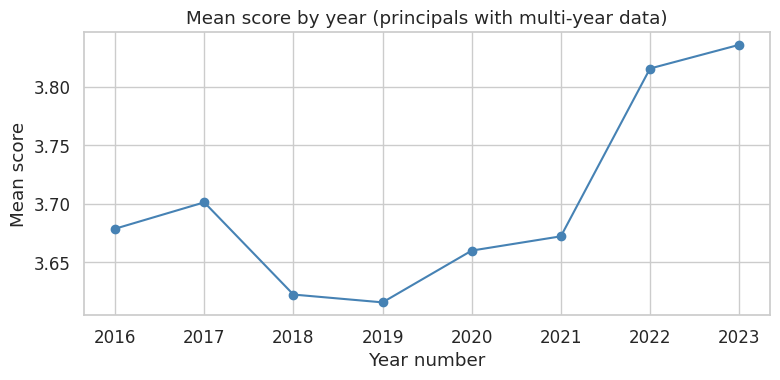

In [23]:
# score trajectory per principal — does scoring improve over years?
if 'PersonId' in df.columns and 'year_num' in df.columns:
    multi_year = scored.groupby('PersonId').filter(lambda x: x['year_num'].nunique() > 1)
    print(f'Principals with multi-year data: {multi_year["PersonId"].nunique():,}')
    
    if len(multi_year) > 0:
        # mean score trajectory
        traj = multi_year.groupby('year_num')[score_col].mean()
        traj.plot(marker='o', figsize=(8, 4), color='steelblue')
        plt.title('Mean score by year (principals with multi-year data)')
        plt.xlabel('Year number')
        plt.ylabel('Mean score')
        plt.tight_layout()
        plt.savefig('../results/diagnostics/score_trajectory.png', dpi=150, bbox_inches='tight')
        plt.show()

## 9. Data Quality Flags

In [24]:
# comprehensive data quality summary
issues = []

# missing text
empty_text = (df[text_col].fillna('').str.strip() == '')
issues.append(('Empty BIP text', empty_text.sum(), empty_text.mean()*100))

# missing scores
missing_score = df[score_col].isnull()
issues.append(('Missing score', missing_score.sum(), missing_score.mean()*100))

# very short BIPs
token_counts_all = df[text_col].fillna('').apply(lambda x: len(x.split()))
short_bip = token_counts_all < 50
issues.append(('< 50 token BIPs', short_bip.sum(), short_bip.mean()*100))

# duplicate texts
dup_text = df[text_col].duplicated(keep=False)
issues.append(('Duplicate text (any)', dup_text.sum(), dup_text.mean()*100))

print('=== Data Quality Summary ===')
print(f'{"Issue":<30} {"Count":>10} {"Pct":>8}')
print('-' * 50)
for label, count, pct in issues:
    print(f'{label:<30} {count:>10,} {pct:>7.1f}%')

# usable BIPs for style learner training (has text, not too short)
usable = (~empty_text) & (token_counts_all >= 50)
print(f'\nUsable for style learner (text >= 50 tokens): {usable.sum():,} / {len(df):,}')

# usable for scored training pool
usable_scored = usable & (~missing_score)
print(f'Usable scored BIPs (text >= 50 tokens + has score): {usable_scored.sum():,}')

=== Data Quality Summary ===
Issue                               Count      Pct
--------------------------------------------------
Empty BIP text                      1,319     6.7%
Missing score                       5,848    29.7%
< 50 token BIPs                     6,074    30.8%
Duplicate text (any)                4,925    25.0%

Usable for style learner (text >= 50 tokens): 13,645 / 19,719
Usable scored BIPs (text >= 50 tokens + has score): 10,237


## 10. Pipeline Config Recommendations

In [25]:
# derive concrete numbers for config.py from the EDA
scored_usable = scored[usable_scored]

score_dist = scored_usable[score_col].value_counts().sort_index()
min_count = score_dist.min()
max_count = score_dist.max()
rarest_level = score_dist.idxmin()

p10 = int(scored_usable['token_count'].quantile(0.10))
p50 = int(scored_usable['token_count'].quantile(0.50))
p90 = int(scored_usable['token_count'].quantile(0.90))
p99 = int(scored_usable['token_count'].quantile(0.99))

print('=' * 55)
print('PIPELINE CONFIG RECOMMENDATIONS')
print('=' * 55)
print(f'\n--- AnchorSamplerConfig ---')
print(f'Score distribution: {score_dist.to_dict()}')
print(f'Rarest level: {rarest_level} ({min_count:,} BIPs)')
print(f'Most common level: {score_dist.idxmax()} ({max_count:,} BIPs)')
print(f'Imbalance ratio: {max_count/min_count:.1f}x')
print(f'→ n_per_level: ~{min_count} (cap at rarest) OR oversample via weighting')

print(f'\n--- GenerationConfig ---')
print(f'Token count: p10={p10}, p50={p50}, p90={p90}, p99={p99}')
print(f'→ max_tokens target: {p90} (covers 90% of real BIP lengths)')
print(f'→ Instruct generation prompt: aim for {p50}–{p90} tokens')

print(f'\n--- StyleLearnerConfig ---')
print(f'→ max_seq_length: {min(p99 + 256, 4096)} (p99 + buffer, capped at 4096)')
print(f'→ Training samples available: {usable.sum():,}')

print(f'\n--- AuditConfig ---')
if 'DistrictID' in df.columns:
    viable_districts = (district_counts.n_bips >= 30).sum()
    print(f'→ Districts with >= 30 scored BIPs: {viable_districts} (viable for subgroup analysis)')
print(f'→ run_subgroup_analysis: {"True" if viable_districts > 0 else "False — insufficient subgroup sizes"}')

PIPELINE CONFIG RECOMMENDATIONS

--- AnchorSamplerConfig ---
Score distribution: {0.0: 36, 1.0: 66, 2.0: 364, 3.0: 1843, 4.0: 7928}
Rarest level: 0.0 (36 BIPs)
Most common level: 4.0 (7,928 BIPs)
Imbalance ratio: 220.2x
→ n_per_level: ~36 (cap at rarest) OR oversample via weighting

--- GenerationConfig ---
Token count: p10=65, p50=150, p90=469, p99=1297
→ max_tokens target: 469 (covers 90% of real BIP lengths)
→ Instruct generation prompt: aim for 150–469 tokens

--- StyleLearnerConfig ---
→ max_seq_length: 1553 (p99 + buffer, capped at 4096)
→ Training samples available: 13,645

--- AuditConfig ---
→ Districts with >= 30 scored BIPs: 62 (viable for subgroup analysis)
→ run_subgroup_analysis: True


In [26]:
# save a clean summary CSV for reference
summary = {
    'total_bips': len(df),
    'scored_bips': len(scored),
    'usable_bips': int(usable.sum()),
    'usable_scored_bips': int(usable_scored.sum()),
    'n_principals': df['PersonId'].nunique() if 'PersonId' in df.columns else None,
    'n_districts': df['DistrictID'].nunique() if 'DistrictID' in df.columns else None,
    'n_school_years': df['SchoolYear'].nunique() if 'SchoolYear' in df.columns else None,
    'token_p10': p10, 'token_p50': p50, 'token_p90': p90, 'token_p99': p99,
    'score_imbalance_ratio': round(max_count / min_count, 2),
    'rarest_score_level': rarest_level,
    'rarest_score_count': int(min_count),
}
pd.Series(summary).to_csv('../results/diagnostics/corpus_summary.csv', header=False)
print('Saved: results/diagnostics/corpus_summary.csv')
pd.Series(summary)

Saved: results/diagnostics/corpus_summary.csv


total_bips               19719.00
scored_bips              13871.00
usable_bips              13645.00
usable_scored_bips       10237.00
n_principals              1086.00
n_districts                156.00
n_school_years               9.00
token_p10                   65.00
token_p50                  150.00
token_p90                  469.00
token_p99                 1297.00
score_imbalance_ratio      220.22
rarest_score_level           0.00
rarest_score_count          36.00
dtype: float64